<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/develop/Regression%20Models/Weather_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Write a python code to implement a regression model for weather forecasting.**

**Compare simple Regression, Ridge Regression and Lasso Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv('/content/drive/MyDrive/weatherHistory.csv')
dataset= pd.DataFrame(df)
dataset.head(2)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.


In [4]:
dataset.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [5]:
#print(dataset['Precipitation'].unique())
#print(dataset['Precipitation Cover'].unique())
# print(dataset['Wind Gust'].unique())
#print(dataset['Wind Bearing (degrees)'].unique())
#print(dataset['Conditions'].unique())


In [6]:
dataset=dataset.drop(['Formatted Date','Daily Summary',
       'Summary'], axis=1 )

In [7]:
dataset.head()

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51


In [8]:
dataset.isna().sum()

,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0
Pressure (millibars),0


In [9]:
dataset=dataset.fillna(0)

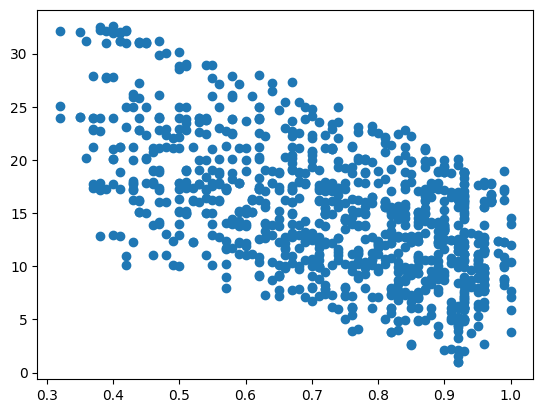

In [10]:
dataset=dataset.rename(columns={'Temperature (C)':'Temperature'})
y_data=np.array((dataset.Temperature).head(1000))
x_data=np.array((dataset.Humidity).head(1000))
plt.scatter(x_data,y_data)
plt.show()

**Linear Regression**


In [11]:
def costFunction(Q0,Q1):
  cost=0
  for i in range(len(x_data)):
     h=Q0+Q1*x_data[i]
     cost+=(h-y_data[i])**2
  cost=cost/(2*len(x_data))
  return cost


In [12]:
def gradientFunction1(Q0,Q1):
  dJq0=0
  for i in range(len(x_data)):
    h=Q0+Q1*x_data[i]
    dJq0+=(h-y_data[i])
  dJq0=dJq0/len(x_data)
  return dJq0;

def gradientFunction2(Q0,Q1):
  dJq1=0
  for i in range(len(x_data)):
    h=Q0+Q1*x_data[i]
    dJq1+=((h-y_data[i])*x_data[i])
  dJq1=dJq1/len(x_data)
  return dJq1

In [13]:
def gradientDescent(learning_rate,iteration):
  Q0=0
  Q1=0
  for i in range(iteration):
    Q0=Q0-learning_rate*(gradientFunction1(Q0,Q1))
    Q1=Q1-learning_rate*(gradientFunction2(Q0,Q1))
    if(i%100==0):
      print("Cost at ",i," position = ",costFunction(Q0,Q1))
  return Q0,Q1



In [14]:
learning_rate=0.1
iteration=len(x_data)
print("Cost before: ",costFunction(0,0))
q0,q1=gradientDescent(learning_rate,iteration)
print("Cost after: ",costFunction(q0,q1))
print(f"q0: {q0:.4f},q1:{q1:.4f}")

Cost before:  132.58307424382718
Cost at  0  position =  102.65723340113101
Cost at  100  position =  20.23697517480707
Cost at  200  position =  17.730781730484804
Cost at  300  position =  16.06522850152146
Cost at  400  position =  14.958343632053277
Cost at  500  position =  14.22273573135582
Cost at  600  position =  13.733869184802963
Cost at  700  position =  13.408980748841447
Cost at  800  position =  13.193068049218647
Cost at  900  position =  13.049577888602592
Cost after:  12.954991515467169
q0: 27.4500,q1:-17.0171


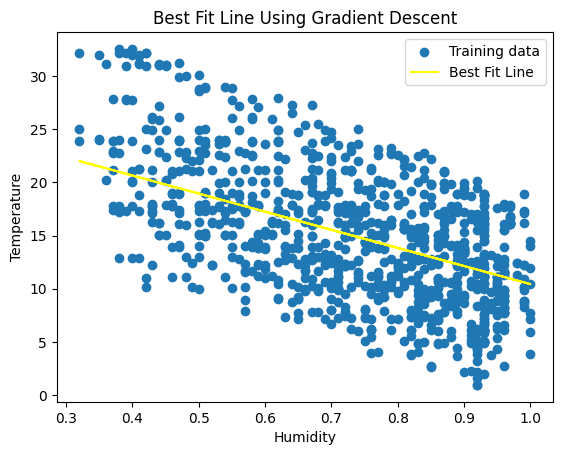

In [15]:
plt.scatter(x_data, y_data, label='Training data')

predicted_y =[]

for i in range(len(x_data)):
  h = q1*x_data[i] + q0
  predicted_y.append(h)

plt.plot(x_data, predicted_y, color='yellow', label='Best Fit Line')

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Best Fit Line Using Gradient Descent")
plt.legend()
plt.show()

**LASSO REGRESSION (L1 Regularization)**

In [16]:
def cost_function_lasso(Q0,Q1,lam):
  cost=0
  reg=0
  m=len(x_data)
  for i in range(len(x_data)):
    h=Q0+Q1*x_data[i]
    cost+=(h-y_data[i])**2
    reg=abs(Q1)
  cost=cost/(2*m)+lam*reg
  return cost

In [17]:
def gradientFunctionLasso(Q0,Q1,lam):
  q0,q1=0,0
  reg=0
  for i in range(len(x_data)):
    h=Q0+Q1*x_data[i]
    q0+=(h-y_data[i])
    q1+=((h-y_data[i])*x_data[i])
    reg=np.sign(q1)
  q0=q0/len(x_data)
  q1=q1/len(x_data)+lam*reg
  return q0,q1


In [18]:
def gradientDescentLasso(learning_rate,lam):
  Q0=0
  Q1=0
  for i in range(len(x_data)):
    q0,q1=gradientFunctionLasso(Q0,Q1,lam)
    Q0=Q0-(learning_rate*q0)
    Q1=Q1-(learning_rate*q1)
    if(i%100==0):
      print("Cost at ",i," position = ",cost_function_lasso(Q0,Q1,lam))
  return Q0,Q1

In [19]:
learning_rate=0.1
lam=1
print("Cost before: ",cost_function_lasso(0,0,lam))
q0,q1=gradientDescentLasso(learning_rate,lam)
print("Cost after: ",cost_function_lasso(q0,q1,lam))
print(f"q0: {q0:.4f},q1:{q1:.4f}")

Cost before:  132.58307424382718
Cost at  0  position =  101.96747278638696
Cost at  100  position =  20.415083041100875
Cost at  200  position =  24.043831168268834
Cost at  300  position =  27.109855027708342
Cost at  400  position =  29.38510965031346
Cost at  500  position =  30.72817487551486
Cost at  600  position =  31.58172750405594
Cost at  700  position =  32.02242629767271
Cost at  800  position =  32.25619092411482
Cost at  900  position =  32.44948063357293
Cost after:  32.50607428485822
q0: 29.5163,q1:-19.7305


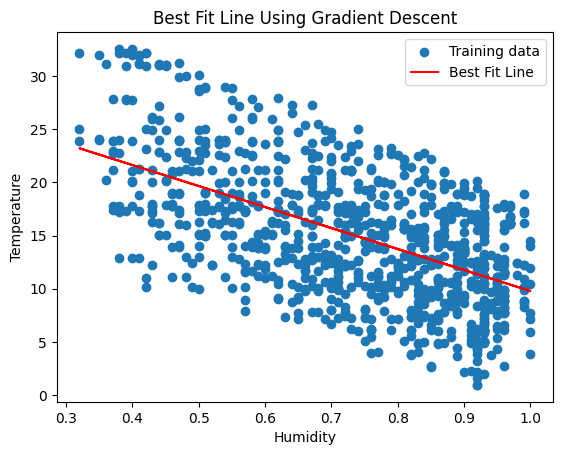

In [20]:
plt.scatter(x_data, y_data, label='Training data')

predicted_y_lasso =[]

for i in range(len(x_data)):
  h = q1*x_data[i] + q0
  predicted_y_lasso.append(h)

plt.plot(x_data, predicted_y_lasso, color='red', label='Best Fit Line')

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Best Fit Line Using Gradient Descent")
plt.legend()
plt.show()

**RIDGE REGRESSION (L2 Regularization)**

Cost function=

In [27]:
def cost_function_ridge(Q0,Q1,lam):
  cost=0
  m=len(x_data)
  for i in range(len(x_data)):
    h=Q0+Q1*x_data[i]
    cost += (h-y_data[i])**2
  reg=lam*(Q1**2)
  cost=(cost/(2*len(x_data)))+reg
  return cost


In [28]:
def gradientFunctionRidge(Q0,Q1,lam):
  q0,q1=0,0
  m=len(x_data)
  for i in range(m):
    h=Q0+Q1*x_data[i]
    q0+=(h-y_data[i])
    q1+=((h-y_data[i])*x_data[i])
  q0=q0/m
  q1=(q1/m)+(lam*2*Q1)
  return q0,q1

In [29]:
def gradientDescentRidge(learning_rate,lam):
  Q0,Q1=0,0
  for i in range(len(x_data)):
    q0,q1=gradientFunctionRidge(Q0,Q1,lam)
    Q0=Q0-(learning_rate*q0)
    Q1=Q1-(learning_rate*q1)
    if(i%100==0):
      print("Cost at ",i," position = ",cost_function_ridge(Q0,Q1,lam))
  return Q0,Q1


In [40]:
learning_rate=0.01
lam=0.5
print("Cost before: ",cost_function_ridge(0,0,lam))
q0,q1=gradientDescentRidge(learning_rate,lam)
print("Cost after: ",cost_function_ridge(q0,q1,lam))
print(f"q0: {q0:.4f},q1:{q1:.4f}")

Cost before:  132.58307424382718
Cost at  0  position =  129.26729045346596
Cost at  100  position =  35.68999089700889
Cost at  200  position =  24.77003447923404
Cost at  300  position =  21.11290499625383
Cost at  400  position =  19.772749919608867
Cost at  500  position =  19.279703727006364
Cost at  600  position =  19.098280867796607
Cost at  700  position =  19.031523469464585
Cost at  800  position =  19.006959026288367
Cost at  900  position =  18.997920149835906
Cost after:  18.994613608165203
q0: 15.4304,q1:-0.5564


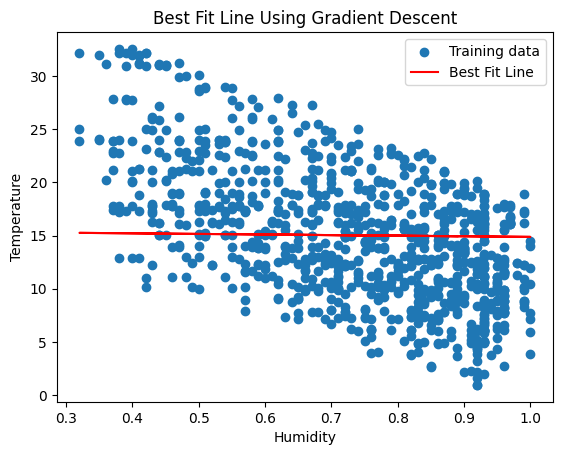

In [41]:
plt.scatter(x_data, y_data, label='Training data')

predicted_y_ridge =[]

for i in range(len(x_data)):
  h = q1*x_data[i] + q0
  predicted_y_ridge.append(h)

plt.plot(x_data, predicted_y_ridge, color='red', label='Best Fit Line')

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Best Fit Line Using Gradient Descent")
plt.legend()
plt.show()

**Comparison between simple Regression, Ridge Regression and Lasso Regression**

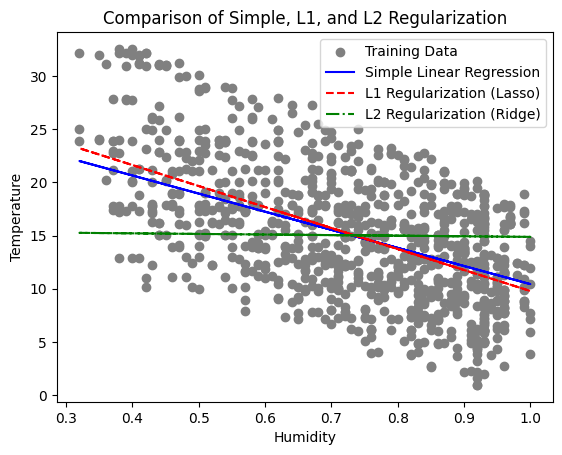

In [42]:
plt.scatter(x_data, y_data, color='GREY', label='Training Data')

# Plot regression lines
plt.plot(x_data, predicted_y, color='blue', label='Simple Linear Regression')
plt.plot(x_data, predicted_y_lasso, color='red', linestyle='--', label='L1 Regularization (Lasso)')
plt.plot(x_data, predicted_y_ridge, color='green', linestyle='-.', label='L2 Regularization (Ridge)')

# Labels and legend
plt.xlabel('Humidity')
plt.ylabel('Temperature')
plt.title('Comparison of Simple, L1, and L2 Regularization')
plt.legend()
# plt.grid(True)
plt.show()